In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Early stopping class

In [2]:
class EarlyStopping:
    def __init__(self, patience=15, delta=0.0001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# Weighted MSE loss

In [3]:
class WeightedMSELoss(nn.Module):
    """
    MSE Loss that gives more weight to higher target values.
    This helps the model learn to predict rare high CISI values better.
    """
    def __init__(self, weight_factor=10.0):
        super().__init__()
        self.weight_factor = weight_factor
    
    def forward(self, pred, target):
        # Higher CISI values get more weight
        # Weight = 1 + weight_factor * target
        weights = 1.0 + self.weight_factor * target
        
        squared_error = (pred - target) ** 2
        weighted_loss = weights * squared_error
        
        return weighted_loss.mean()

# CNN Model

In [4]:
class CNN(nn.Module):
    def __init__(self, config):
        super(CNN, self).__init__()

        self.config = config

        # 3 Layers of the CNN
        self.conv_layers = nn.Sequential(
            nn.Conv2d(9, 16, kernel_size=3, padding=1), # 9 channels
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # New layer
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),
        )

        # Makes model patch-size independent
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully connected regression head
        self.fc_layers = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc_layers(x)
        x = torch.sigmoid(x) # Sigmoid activation function
        # x = torch.clamp(x, 0, 1) # Linear clip to valid range
        return x


# Dataset Class

In [5]:
class CISIDataset(Dataset):
    def __init__(self, gdp_path, pop_path, lc_path, cisi_path):
        # Load all data
        with rasterio.open(gdp_path) as src:
            self.gdp = src.read(1)  # Shape: (H, W)
        
        with rasterio.open(pop_path) as src:
            self.pop = src.read(1)
        
        with rasterio.open(lc_path) as src:
            self.lc = src.read()  # Shape: (7, H, W) - all one-hot channels
        
        with rasterio.open(cisi_path) as src:
            self.cisi = src.read(1)
        
        # Get valid indices (where CISI is not NaN/nodata)
        self.valid_mask = ~np.isnan(self.cisi)
        self.valid_indices = np.argwhere(self.valid_mask)
        
        print(f"Found {len(self.valid_indices)} valid pixels")
    
    def __len__(self):
        return len(self.valid_indices)
    
    # def __getitem__(self, idx):
    #     i, j = self.valid_indices[idx]
        
    #     # 32x32 patch for now, currently no stride.
    #     patch_size = 32
    #     half_patch = patch_size // 2
        
    #     # Handle boundaries
    #     i_start = max(0, i - half_patch)
    #     i_end = min(self.gdp.shape[0], i + half_patch)
    #     j_start = max(0, j - half_patch)
    #     j_end = min(self.gdp.shape[1], j + half_patch)
        
    #     # Extract patches
    #     gdp_patch = self.gdp[i_start:i_end, j_start:j_end]
    #     pop_patch = self.pop[i_start:i_end, j_start:j_end]
    #     lc_patch = self.lc[:, i_start:i_end, j_start:j_end]
        
    #     # Pad to patch_size if needed
    #     pad_i = patch_size - gdp_patch.shape[0]
    #     pad_j = patch_size - gdp_patch.shape[1]
        
    #     if pad_i > 0 or pad_j > 0:
    #         gdp_patch = np.pad(gdp_patch, ((0, pad_i), (0, pad_j)))
    #         pop_patch = np.pad(pop_patch, ((0, pad_i), (0, pad_j)))
    #         lc_patch = np.pad(lc_patch, ((0, 0), (0, pad_i), (0, pad_j)))
        
    #     # Stack: (9, 32, 32)
    #     input_tensor = np.stack([
    #         gdp_patch,
    #         pop_patch,
    #         *lc_patch  # Unpack all 7 LC channels
    #     ], axis=0)
        
    #     # Get target CISI value
    #     target = self.cisi[i, j]
        
    #     # Convert to tensors
    #     input_tensor = torch.FloatTensor(input_tensor)
    #     target = torch.FloatTensor([target])
        
    #     return input_tensor, target, (i, j)

    def __getitem__(self, idx): # ChatGPT version
        patch_size = 32
        half_patch = patch_size // 2

        max_tries = 50
        tries = 0

        while True:
            i, j = self.valid_indices[idx]

            # Handle boundaries
            i_start = max(0, i - half_patch)
            i_end = min(self.gdp.shape[0], i + half_patch)
            j_start = max(0, j - half_patch)
            j_end = min(self.gdp.shape[1], j + half_patch)

            # Extract patches
            gdp_patch = self.gdp[i_start:i_end, j_start:j_end]
            pop_patch = self.pop[i_start:i_end, j_start:j_end]
            lc_patch  = self.lc[:, i_start:i_end, j_start:j_end]

            # Pad to patch_size if needed
            pad_i = patch_size - gdp_patch.shape[0]
            pad_j = patch_size - gdp_patch.shape[1]

            if pad_i > 0 or pad_j > 0:
                gdp_patch = np.pad(gdp_patch, ((0, pad_i), (0, pad_j)))
                pop_patch = np.pad(pop_patch, ((0, pad_i), (0, pad_j)))
                lc_patch  = np.pad(lc_patch, ((0, 0), (0, pad_i), (0, pad_j)))

            # >>> ADD THIS MASKING CHECK (AFTER PADDING, BEFORE STACKING) <<<
            if np.isfinite(gdp_patch).all() and np.isfinite(pop_patch).all():
                break  # patch is safe to use

            # otherwise try a different index
            tries += 1
            if tries >= max_tries:
                # last resort: fill NaNs so you never return NaNs
                gdp_patch = np.nan_to_num(gdp_patch, nan=0.0, posinf=0.0, neginf=0.0)
                pop_patch = np.nan_to_num(pop_patch, nan=0.0, posinf=0.0, neginf=0.0)
                break

            idx = np.random.randint(0, len(self.valid_indices))
            # <<< END MASKING CHECK <<<

        # Stack: (9, 32, 32)
        input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)

        # Target CISI at center pixel (as you had)
        target = self.cisi[i, j]

        input_tensor = torch.FloatTensor(input_tensor)
        target = torch.FloatTensor([target])

        return input_tensor, target, (i, j)



# Training Function

In [6]:
def training(
    num_epochs,
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    clip_value,
    device,
    wandbrun=None,
    sigmoidcnn=False
):
    train_loss_list = []
    val_loss_list = []

    early_stopping = EarlyStopping()

    for epoch in range(num_epochs):
        # ========== TRAINING ==========
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            inputs, targets, _ = batch
            inputs = inputs.to(device)
            targets = targets.to(device).view(-1, 1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_loss_list.append(avg_train_loss)

        # ========== VALIDATION ==========
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                inputs, targets, _ = batch
                inputs = inputs.to(device)
                targets = targets.to(device).view(-1, 1)

                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_loss_list.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Early stopping check
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    return train_loss_list, val_loss_list

# Paths 0.25

In [7]:
gdp_path = r"READY_data\inputs_normalized\2019_gdp_aligned_025_normalized.tif"
pop_path = r"READY_data\inputs_normalized\2020_pop_aligned_025_normalized.tif"
lc_path = r"READY_data\landuse_onehot_025\clipped_history_2020_025_onehot.tif"
cisi_path = r"READY_data\labels\2024_CISI_025deg.tif"

# Dataset and Split

In [8]:
# Create full dataset
dataset = CISIDataset(gdp_path, pop_path, lc_path, cisi_path)

# Split: 80% train, 20% validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"Train samples: {train_size}")
print(f"Validation samples: {val_size}")

Found 14922 valid pixels
Train samples: 11937
Validation samples: 2985


# Create Dataloaders

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, drop_last=True)

TRAIN SET:
  Mean: 0.0372, Std: 0.0366
  Range: [0.0000, 0.5907]

VAL SET:
  Mean: 0.0376, Std: 0.0383
  Range: [0.0000, 0.3465]


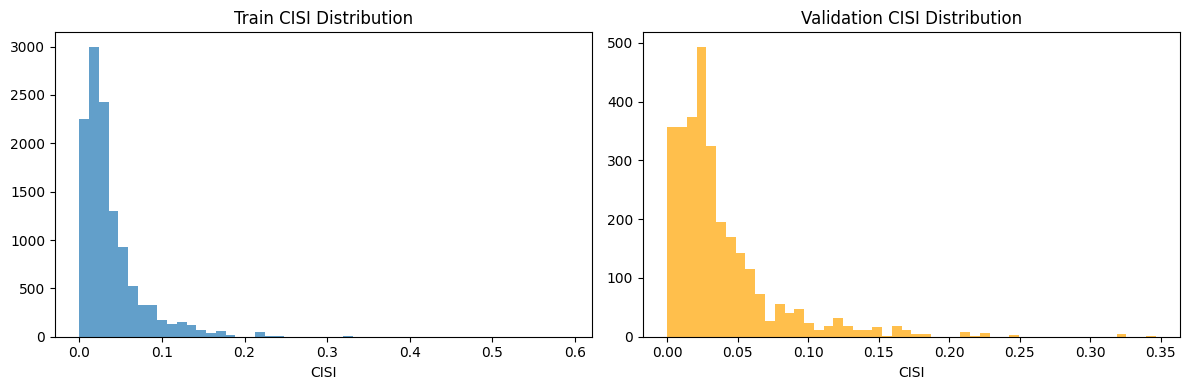

In [10]:
train_targets = []
val_targets = []

for _, target, _ in train_loader:
    train_targets.extend(target.numpy().flatten())

for _, target, _ in val_loader:
    val_targets.extend(target.numpy().flatten())

train_targets = np.array(train_targets)
val_targets = np.array(val_targets)

print("TRAIN SET:")
print(f"  Mean: {train_targets.mean():.4f}, Std: {train_targets.std():.4f}")
print(f"  Range: [{train_targets.min():.4f}, {train_targets.max():.4f}]")

print("\nVAL SET:")
print(f"  Mean: {val_targets.mean():.4f}, Std: {val_targets.std():.4f}")
print(f"  Range: [{val_targets.min():.4f}, {val_targets.max():.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_targets, bins=50, alpha=0.7, label='Train')
axes[0].set_title('Train CISI Distribution')
axes[0].set_xlabel('CISI')

axes[1].hist(val_targets, bins=50, alpha=0.7, label='Val', color='orange')
axes[1].set_title('Validation CISI Distribution')
axes[1].set_xlabel('CISI')

plt.tight_layout()
plt.show()

# Init Model

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

config = {'dropout': 0.3}
model = CNN(config).to(device)

# criterion = nn.HuberLoss(delta=1.0)
criterion = WeightedMSELoss(weight_factor=10.0) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # Learning rate 

Using device: cpu


# Train Model

In [12]:
train_loss_list, val_loss_list = training(
    num_epochs=50,
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    clip_value=1.0,
    device=device
)

Epoch [1/50] - Train Loss: 0.0725, Val Loss: 0.0379
Epoch [2/50] - Train Loss: 0.0094, Val Loss: 0.0107
Epoch [3/50] - Train Loss: 0.0049, Val Loss: 0.0050
Epoch [4/50] - Train Loss: 0.0038, Val Loss: 0.0023
Epoch [5/50] - Train Loss: 0.0034, Val Loss: 0.0020
Epoch [6/50] - Train Loss: 0.0031, Val Loss: 0.0023
Epoch [7/50] - Train Loss: 0.0031, Val Loss: 0.0027
Epoch [8/50] - Train Loss: 0.0029, Val Loss: 0.0020
Epoch [9/50] - Train Loss: 0.0026, Val Loss: 0.0036
Epoch [10/50] - Train Loss: 0.0026, Val Loss: 0.0025
Epoch [11/50] - Train Loss: 0.0025, Val Loss: 0.0028
Epoch [12/50] - Train Loss: 0.0023, Val Loss: 0.0029
Epoch [13/50] - Train Loss: 0.0023, Val Loss: 0.0030
Epoch [14/50] - Train Loss: 0.0020, Val Loss: 0.0025
Epoch [15/50] - Train Loss: 0.0019, Val Loss: 0.0028
Epoch [16/50] - Train Loss: 0.0019, Val Loss: 0.0026
Epoch [17/50] - Train Loss: 0.0019, Val Loss: 0.0035
Epoch [18/50] - Train Loss: 0.0017, Val Loss: 0.0036
Epoch [19/50] - Train Loss: 0.0017, Val Loss: 0.0018
Ep

# Plotting some results

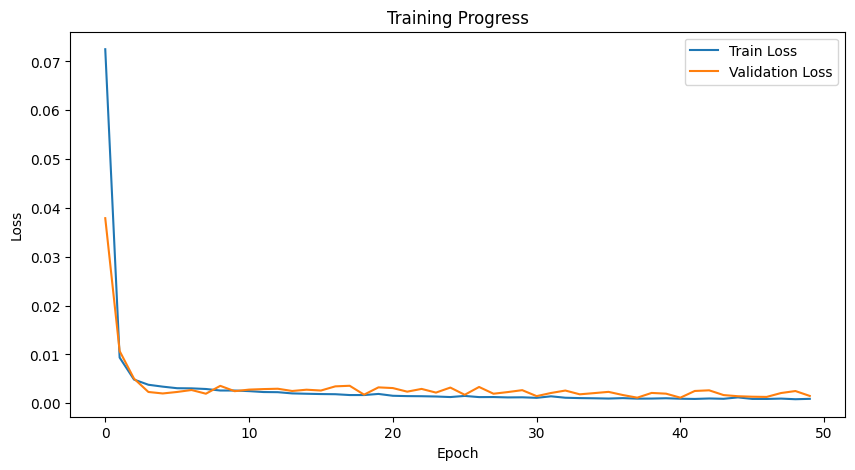

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Progress')
plt.show()

# Generate predictions

In [14]:
model.eval()
predictions = []
actuals = []
coordinates = []

with torch.no_grad():
    for batch in val_loader:
        inputs, targets, coords = batch
        inputs = inputs.to(device)
        
        outputs = model(inputs)
        
        predictions.extend(outputs.cpu().numpy().flatten())
        actuals.extend(targets.numpy().flatten())
        coordinates.extend(coords)

predictions = np.array(predictions)
actuals = np.array(actuals)

print(f"Predictions range: [{predictions.min():.3f}, {predictions.max():.3f}]")
print(f"Actuals range: [{actuals.min():.3f}, {actuals.max():.3f}]")

Predictions range: [0.005, 0.178]
Actuals range: [0.000, 0.325]


# Visualize Results

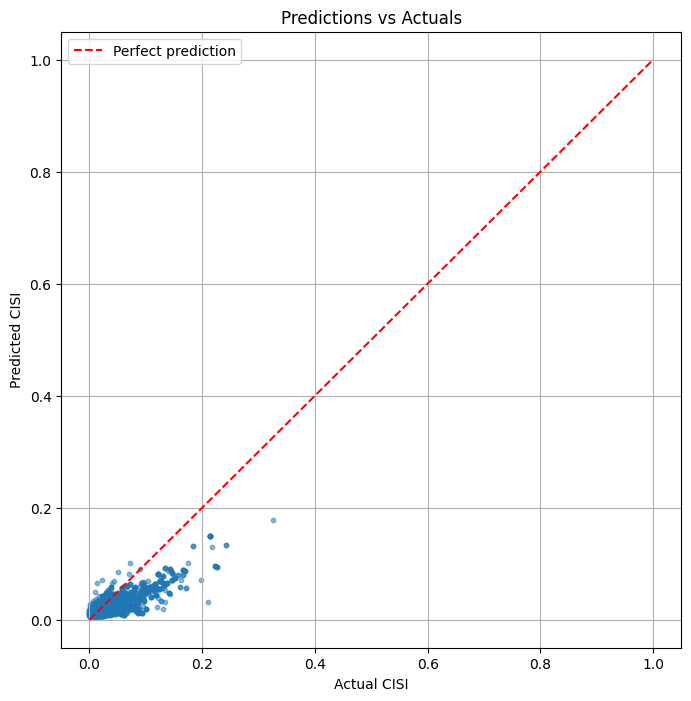

In [15]:
plt.figure(figsize=(8, 8))
plt.scatter(actuals, predictions, alpha=0.5, s=10)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
plt.xlabel('Actual CISI')
plt.ylabel('Predicted CISI')
plt.title('Predictions vs Actuals')
plt.legend()
plt.grid(True)
plt.show()

# Metrics

In [16]:
mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(actuals, predictions)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MSE: 0.0007
MAE: 0.0181
RMSE: 0.0263
R² Score: 0.4194


=== ACTUALS ===
Mean: 0.0371
Std: 0.0345
Range: [0.0000, 0.3249]

=== PREDICTIONS ===
Mean: 0.0231
Std: 0.0176
Range: [0.0051, 0.1783]


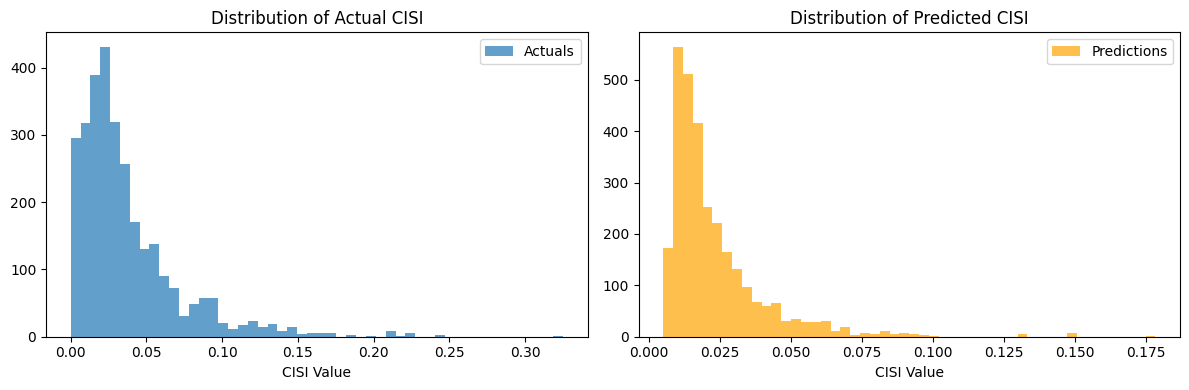

In [17]:
# Check distributions
print("=== ACTUALS ===")
print(f"Mean: {actuals.mean():.4f}")
print(f"Std: {actuals.std():.4f}")
print(f"Range: [{actuals.min():.4f}, {actuals.max():.4f}]")

print("\n=== PREDICTIONS ===")
print(f"Mean: {predictions.mean():.4f}")
print(f"Std: {predictions.std():.4f}")
print(f"Range: [{predictions.min():.4f}, {predictions.max():.4f}]")

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(actuals, bins=50, alpha=0.7, label='Actuals')
axes[0].set_title('Distribution of Actual CISI')
axes[0].set_xlabel('CISI Value')
axes[0].legend()

axes[1].hist(predictions, bins=50, alpha=0.7, label='Predictions', color='orange')
axes[1].set_title('Distribution of Predicted CISI')
axes[1].set_xlabel('CISI Value')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Look at one sample from dataset
sample_input, sample_target, _ = dataset[0]

print("Input shape:", sample_input.shape)
print("\nInput statistics per channel:")
for i in range(9):
    channel = sample_input[i]
    print(f"Channel {i}: min={channel.min():.2f}, max={channel.max():.2f}, mean={channel.mean():.2f}")

print(f"\nTarget CISI value: {sample_target.item():.4f}")

Input shape: torch.Size([9, 32, 32])

Input statistics per channel:
Channel 0: min=-0.95, max=2.27, mean=-0.45
Channel 1: min=-1.00, max=1.76, mean=0.15
Channel 2: min=0.00, max=0.00, mean=0.00
Channel 3: min=0.00, max=1.00, mean=0.32
Channel 4: min=0.00, max=1.00, mean=0.39
Channel 5: min=0.00, max=1.00, mean=0.01
Channel 6: min=0.00, max=0.00, mean=0.00
Channel 7: min=0.00, max=0.00, mean=0.00
Channel 8: min=0.00, max=0.00, mean=0.00

Target CISI value: 0.1715


# Save model

In [1]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_loss_list,
    'val_loss': val_loss_list,
    'config': config
}, 'cisi_model_2024.pth')

print("Model saved!")

NameError: name 'torch' is not defined

# Debugging checks

In [20]:
import torch
import numpy as np

print("=" * 70)
print("CHECKING FIRST BATCH FROM DATALOADER")
print("=" * 70)

# Get one batch
for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
    print(f"\nBatch {batch_idx}:")
    print(f"  Batch size: {inputs.shape[0]}")
    print(f"  Input shape: {inputs.shape}")  # Should be (batch, 9, 32, 32)
    print(f"  Target shape: {targets.shape}")  # Should be (batch, 1)
    
    # Check for NaN/Inf in inputs
    print(f"\n  INPUT CHECKS:")
    print(f"    Contains NaN: {torch.isnan(inputs).any().item()}")
    print(f"    Contains Inf: {torch.isinf(inputs).any().item()}")
    print(f"    Min: {inputs.min().item():.4f}")
    print(f"    Max: {inputs.max().item():.4f}")
    print(f"    Mean: {inputs.mean().item():.4f}")
    
    # Check for NaN/Inf in targets
    print(f"\n  TARGET CHECKS:")
    print(f"    Contains NaN: {torch.isnan(targets).any().item()}")
    print(f"    Contains Inf: {torch.isinf(targets).any().item()}")
    print(f"    Min: {targets.min().item():.4f}")
    print(f"    Max: {targets.max().item():.4f}")
    print(f"    Mean: {targets.mean().item():.4f}")
    
    # Check each channel individually
    print(f"\n  PER-CHANNEL CHECKS:")
    channel_names = ['GDP', 'Pop', 'LC_0', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6']
    for ch in range(9):
        ch_data = inputs[:, ch, :, :]
        has_nan = torch.isnan(ch_data).any().item()
        has_inf = torch.isinf(ch_data).any().item()
        print(f"    {channel_names[ch]:6s}: min={ch_data.min().item():7.2f}, "
              f"max={ch_data.max().item():7.2f}, "
              f"NaN={has_nan}, Inf={has_inf}")
    
    # Only check first batch
    break

print("\n" + "=" * 70)

CHECKING FIRST BATCH FROM DATALOADER

Batch 0:
  Batch size: 32
  Input shape: torch.Size([32, 9, 32, 32])
  Target shape: torch.Size([32, 1])

  INPUT CHECKS:
    Contains NaN: False
    Contains Inf: False
    Min: -2.2972
    Max: 3.9307
    Mean: 0.1191

  TARGET CHECKS:
    Contains NaN: False
    Contains Inf: False
    Min: 0.0003
    Max: 0.1317
    Mean: 0.0296

  PER-CHANNEL CHECKS:
    GDP   : min=  -1.05, max=   3.93, NaN=False, Inf=False
    Pop   : min=  -2.30, max=   2.13, NaN=False, Inf=False
    LC_0  : min=   0.00, max=   1.00, NaN=False, Inf=False
    LC_1  : min=   0.00, max=   1.00, NaN=False, Inf=False
    LC_2  : min=   0.00, max=   1.00, NaN=False, Inf=False
    LC_3  : min=   0.00, max=   1.00, NaN=False, Inf=False
    LC_4  : min=   0.00, max=   1.00, NaN=False, Inf=False
    LC_5  : min=   0.00, max=   1.00, NaN=False, Inf=False
    LC_6  : min=   0.00, max=   1.00, NaN=False, Inf=False



In [21]:
print("=" * 70)
print("TESTING FORWARD PASS")
print("=" * 70)

model.eval()  # Set to eval mode first
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
        inputs = inputs.to(device)
        targets = targets.to(device).view(-1, 1)
        
        print(f"\nBatch {batch_idx}:")
        print(f"  Input device: {inputs.device}")
        print(f"  Input requires_grad: {inputs.requires_grad}")
        
        # Forward pass
        try:
            outputs = model(inputs)
            
            print(f"\n  OUTPUT CHECKS:")
            print(f"    Output shape: {outputs.shape}")
            print(f"    Contains NaN: {torch.isnan(outputs).any().item()}")
            print(f"    Contains Inf: {torch.isinf(outputs).any().item()}")
            print(f"    Min: {outputs.min().item():.4f}")
            print(f"    Max: {outputs.max().item():.4f}")
            print(f"    Mean: {outputs.mean().item():.4f}")
            
            # Compute loss
            loss = criterion(outputs, targets)
            print(f"\n  LOSS:")
            print(f"    Loss value: {loss.item():.4f}")
            print(f"    Loss is NaN: {torch.isnan(loss).item()}")
            print(f"    Loss is Inf: {torch.isinf(loss).item()}")
            
        except Exception as e:
            print(f"  ❌ ERROR during forward pass: {e}")
            import traceback
            traceback.print_exc()
        
        # Only test first batch
        break

print("\n" + "=" * 70)

TESTING FORWARD PASS

Batch 0:
  Input device: cpu
  Input requires_grad: False

  OUTPUT CHECKS:
    Output shape: torch.Size([32, 1])
    Contains NaN: False
    Contains Inf: False
    Min: 0.0100
    Max: 0.0768
    Mean: 0.0250

  LOSS:
    Loss value: 0.0017
    Loss is NaN: False
    Loss is Inf: False



In [22]:
print("=" * 70)
print("DEBUGGING ONE TRAINING STEP")
print("=" * 70)

model.train()

for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
    inputs = inputs.to(device)
    targets = targets.to(device).view(-1, 1)
    
    print(f"\n=== STEP {batch_idx} ===")
    
    # Zero gradients
    optimizer.zero_grad()
    
    # Forward
    print("1. Forward pass...")
    outputs = model(inputs)
    print(f"   Outputs: min={outputs.min().item():.4f}, max={outputs.max().item():.4f}, "
          f"NaN={torch.isnan(outputs).any().item()}")
    
    # Loss
    print("2. Computing loss...")
    loss = criterion(outputs, targets)
    print(f"   Loss: {loss.item():.4f}, NaN={torch.isnan(loss).item()}")
    
    if torch.isnan(loss):
        print("   ❌ NaN DETECTED IN LOSS!")
        print(f"   Sample outputs: {outputs[:5].squeeze()}")
        print(f"   Sample targets: {targets[:5].squeeze()}")
        break
    
    # Backward
    print("3. Backward pass...")
    loss.backward()
    
    # Check gradients
    print("4. Checking gradients...")
    total_norm = 0
    max_grad = 0
    nan_grads = False
    
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_norm = param.grad.data.norm(2).item()
            total_norm += grad_norm ** 2
            max_grad = max(max_grad, param.grad.abs().max().item())
            
            if torch.isnan(param.grad).any():
                print(f"   ❌ NaN gradient in {name}")
                nan_grads = True
    
    total_norm = total_norm ** 0.5
    print(f"   Total gradient norm: {total_norm:.4f}")
    print(f"   Max gradient value: {max_grad:.4f}")
    
    if nan_grads:
        print("   ❌ NaN DETECTED IN GRADIENTS!")
        break
    
    if total_norm > 1000:
        print(f"   ⚠️ WARNING: Very large gradients! (norm={total_norm:.2f})")
    
    # Clip
    print("5. Clipping gradients...")
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
    # Step
    print("6. Optimizer step...")
    optimizer.step()
    
    print("   ✅ Step complete\n")
    
    # Only do 3 steps
    if batch_idx >= 2:
        break

print("\n" + "=" * 70)

DEBUGGING ONE TRAINING STEP

=== STEP 0 ===
1. Forward pass...
   Outputs: min=0.0005, max=0.2137, NaN=False
2. Computing loss...
   Loss: 0.0006, NaN=False
3. Backward pass...
4. Checking gradients...
   Total gradient norm: 0.0109
   Max gradient value: 0.0012
5. Clipping gradients...
6. Optimizer step...
   ✅ Step complete


=== STEP 1 ===
1. Forward pass...
   Outputs: min=0.0018, max=0.2080, NaN=False
2. Computing loss...
   Loss: 0.0008, NaN=False
3. Backward pass...
4. Checking gradients...
   Total gradient norm: 0.0084
   Max gradient value: 0.0011
5. Clipping gradients...
6. Optimizer step...
   ✅ Step complete


=== STEP 2 ===
1. Forward pass...
   Outputs: min=0.0057, max=0.1012, NaN=False
2. Computing loss...
   Loss: 0.0007, NaN=False
3. Backward pass...
4. Checking gradients...
   Total gradient norm: 0.0101
   Max gradient value: 0.0021
5. Clipping gradients...
6. Optimizer step...
   ✅ Step complete




In [23]:
print("=" * 70)
print("CHECKING MODEL WEIGHTS")
print("=" * 70)

print("\nModel parameters:")
for name, param in model.named_parameters():
    print(f"  {name:40s}: shape={str(list(param.shape)):20s} "
          f"mean={param.data.mean().item():8.4f} "
          f"std={param.data.std().item():8.4f} "
          f"NaN={torch.isnan(param.data).any().item()}")

print("\n" + "=" * 70)

CHECKING MODEL WEIGHTS

Model parameters:
  conv_layers.0.weight                    : shape=[16, 9, 3, 3]        mean= -0.0028 std=  0.0991 NaN=False
  conv_layers.0.bias                      : shape=[16]                 mean= -0.0141 std=  0.0890 NaN=False
  conv_layers.1.weight                    : shape=[16]                 mean=  1.0015 std=  0.0460 NaN=False
  conv_layers.1.bias                      : shape=[16]                 mean= -0.1489 std=  0.0488 NaN=False
  conv_layers.5.weight                    : shape=[32, 16, 3, 3]       mean= -0.0023 std=  0.0752 NaN=False
  conv_layers.5.bias                      : shape=[32]                 mean= -0.0140 std=  0.0507 NaN=False
  conv_layers.6.weight                    : shape=[32]                 mean=  0.9886 std=  0.0590 NaN=False
  conv_layers.6.bias                      : shape=[32]                 mean= -0.2194 std=  0.0806 NaN=False
  conv_layers.10.weight                   : shape=[64, 32, 3, 3]       mean= -0.0061 std=  0.0

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_61996\2250598502.py:9: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  f"std={param.data.std().item():8.4f} "


In [3]:
import os
from pathlib import Path

# Check current working directory
print(f"Current directory: {os.getcwd()}")

# List files in current directory
print("\nFiles in current directory:")
for file in Path('.').glob('*.pth'):
    print(f"  ✅ {file}")

# Also check common locations
locations_to_check = [
    '.',
    './models',
    '../',
    str(Path.home() / 'Downloads'),
]

print("\nSearching for .pth files...")
for loc in locations_to_check:
    if os.path.exists(loc):
        pth_files = list(Path(loc).glob('**/*.pth'))
        if pth_files:
            print(f"\n📁 Found in {loc}:")
            for f in pth_files:
                print(f"  ✅ {f}")

Current directory: c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis

Files in current directory:
  ✅ cisi_model_2024.pth

Searching for .pth files...

📁 Found in .:
  ✅ cisi_model_2024.pth

📁 Found in ../:
  ✅ ..\empy_repo_for_thesis\cisi_model_2024.pth
